In [2]:
using DataFrames, CSV, HTTP, Statistics, Plots, StatsBase, GLM, Random #подключаем 8 основных пакетов для работы

In [3]:
println("Загрузка данных...")
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
df = CSV.read(HTTP.get(url).body, DataFrame) #скачиваем датасет пингвинов с github

Загрузка данных...


Row,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,String15,String15,String7,String7,String3,String7,String7,Int64
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18,195,3250,female,2007
4,Adelie,Torgersen,NA,NA,NA,NA,NA,2007
5,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
6,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
7,Adelie,Torgersen,38.9,17.8,181,3625,female,2007
8,Adelie,Torgersen,39.2,19.6,195,4675,male,2007
9,Adelie,Torgersen,34.1,18.1,193,3475,NA,2007


In [7]:
df = dropmissing(df)
filter!(row -> row.sex in ("male", "female"), df) #фильтруем значения

df.bill_length_mm = Float64.(df.bill_length_mm)
df.bill_depth_mm = Float64.(df.bill_depth_mm)
df.flipper_length_mm = Float64.(df.bill_depth_mm)
df.body_mass_g = Float64.(df.body_mass_g)

println("Данные преобразованы в числовой формат")

Данные преобразованы в числовой формат


In [8]:
println("Подготовка данных для регрессии...")

reg_df = DataFrame( #создаем новый датафрейм
    bill_length = Float64.(df.bill_length_mm),
    bill_depth = Float64.(df.bill_depth_mm),
    flipper_length = Float64.(df.flipper_length_mm),
    body_mass = Float64.(df.body_mass_g)
)

println("Типы данных в reg_df:")
for col in names(reg_df)
    println("$col: ", eltype(reg_df[!, col])) #проверяем типы данных
end

n = size(reg_df, 1) #делим данные на обучающую и тестовую выборки
train_size = Int(round(0.8 * n))
indices = shuffle(1:n)
train_indices = indices[1:train_size]
test_indices = indices[train_size+1:end]

train_data = reg_df[train_indices, :]
test_data = reg_df[test_indices, :]

X_train = Matrix(train_data[:, [:bill_length, :bill_depth, :flipper_length]])
X_test = Matrix(test_data[:, [:bill_length, :bill_depth, :flipper_length]])
y_train = train_data.body_mass
y_test = test_data.body_mass

println("Данные разделены: обучающая выборка = ", size(train_data, 1), ", тестовая = ", size(test_data, 1))

Подготовка данных для регрессии...
Типы данных в reg_df:
bill_length: Float64
bill_depth: Float64
flipper_length: Float64
body_mass: Float64
Данные разделены: обучающая выборка = 266, тестовая = 67


In [12]:
function manual_scale(X)
    X_float = Float64.(X)  #двойное преобразование 
    means = mean(X_float, dims=1)
    stds = std(X_float, dims=1)
    stds = [s == 0 ? 1.0 : s for s in stds]  #защиащем от деления на 0
    X_scaled = (X_float .- means) ./ stds
    return X_scaled, means, stds
end
#само масштабирование(тестовые данные масштабируются по параметрам тренированых)
X_train_scaled, train_means, train_stds = manual_scale(X_train)
X_test_scaled = (X_test .- train_means) ./ train_stds

train_scaled_df = DataFrame( #создаем новый датафрейм 
    bill_length = X_train_scaled[:, 1],
    bill_depth = X_train_scaled[:, 2], 
    flipper_length = X_train_scaled[:, 3],
    body_mass = y_train
)
println("Размер обучающей выборки: ", size(train_scaled_df))

Размер обучающей выборки: (266, 4)


In [13]:
model = lm(@formula(body_mass ~ bill_length + bill_depth + flipper_length), train_scaled_df) #обучаем модель

println("\n" * "="^50)
println("МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ")
println("="^50)
display(model) #выводим результаты


МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

body_mass ~ 1 + bill_length + bill_depth + flipper_length

Coefficients:
────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error       t  Pr(>|t|)  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)     4172.09      35.0711  118.96    <1e-99   4103.03    4241.14
bill_length      405.888     35.8966   11.31    <1e-23    335.207    476.57
bill_depth      -268.729     35.8966   -7.49    <1e-11   -339.411   -198.048
flipper_length     0.0      NaN       NaN       NaN       NaN        NaN
────────────────────────────────────────────────────────────────────────────

In [16]:
test_scaled_df = DataFrame( #создаем тестовый датафрем для предсказания
    bill_length = X_test_scaled[:, 1],
    bill_depth = X_test_scaled[:, 2], 
    flipper_length = X_test_scaled[:, 3]
)

y_pred = predict(model, test_scaled_df) #применяем обученнуб модель к тестовым данным

67-element Vector{Union{Missing, Float64}}:
 3748.049512275529
 4472.403711231265
 4650.408704561249
 4718.921395362601
 3730.9297256010886
 4323.279804651038
 3719.7748951898566
 3490.0062287271635
 4523.2236897976845
 3551.5767245954266
 4784.5694583614895
 4751.0714230242065
 4440.691540782637
    ⋮
 4525.548936143245
 4668.134960899771
 3781.1767786070145
 3614.8995412487566
 5010.867027357639
 3494.42102076
 4707.39579594557
 4632.143066765822
 5124.807666022693
 3931.2779238571234
 3524.4479586307393
 3737.8719205341777

In [17]:
println("\n" * "="^50)
println("РЕЗУЛЬТАТЫ РЕГРЕССИИ (ПРЕДСКАЗАНИЕ ВЕСА)")
println("="^50)

mae = mean(abs.(y_test - y_pred)) #функции для расчета вручную

rmse = sqrt(mean((y_test - y_pred).^2))
r2 = 1 - sum((y_test - y_pred).^2) / sum((y_test .- mean(y_test)).^2)

println("MAE (Средняя абсолютная ошибка): ", round(mae, digits=2), " г")
println("RMSE (Среднеквадратичная ошибка): ", round(rmse, digits=2), " г")
println("R² (Коэффициент детерминации): ", round(r2 * 100, digits=2), "%")


РЕЗУЛЬТАТЫ РЕГРЕССИИ (ПРЕДСКАЗАНИЕ ВЕСА)
MAE (Средняя абсолютная ошибка): 526.81 г
RMSE (Среднеквадратичная ошибка): 659.81 г
R² (Коэффициент детерминации): 44.94%


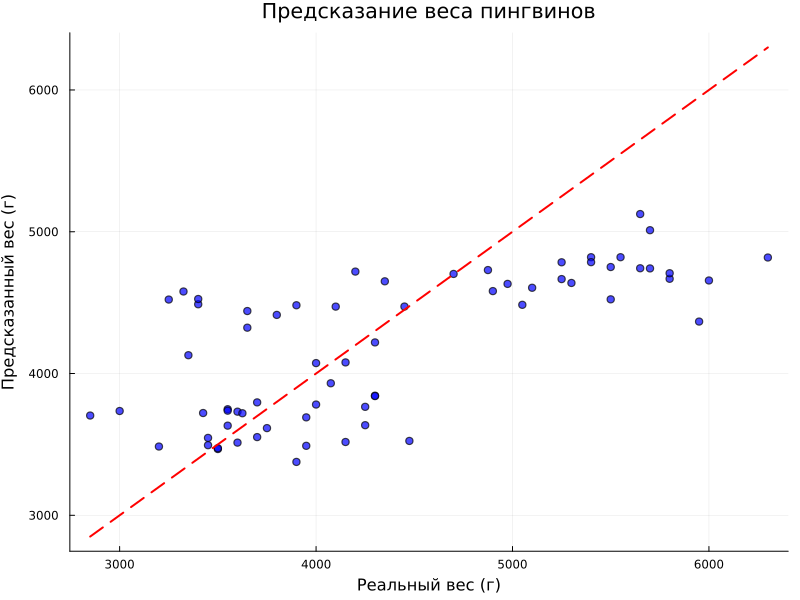

График сохранен как 'regression_plot.png'


In [19]:
p1 = scatter(y_test, y_pred, alpha=0.7, legend=false, #создаем точечный график
        xlabel="Реальный вес (г)", ylabel="Предсказанный вес (г)",
        title="Предсказание веса пингвинов",
        seriescolor=:blue, size=(800, 600))

min_val = minimum([minimum(y_test), minimum(y_pred)]) #создаем линию предсказания
max_val = maximum([maximum(y_test), maximum(y_pred)])
plot!([min_val, max_val], [min_val, max_val], line=:dash, linecolor=:red, linewidth=2)

display(p1)  #выводим видимые результаты
savefig("regression_plot.png")
println("График сохранен как 'regression_plot.png'")


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
Таблица важности признаков:


Row,Признак,Коэффициент,Важность
,String,Float64,Float64
1,Длина клюва,405.888,405.888
2,Глубина клюва,-268.729,268.729
3,Длина ласт,0.0,0.0


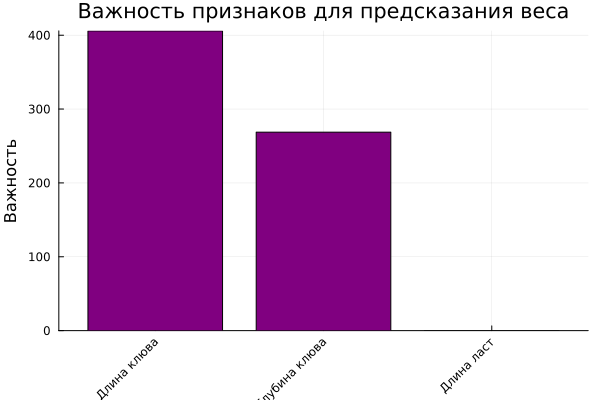

In [20]:
println("\nАНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
println("="^50)

feature_names = ["Длина клюва", "Глубина клюва", "Длина ласт"]
coef_values = coef(model)[2:end]

feature_importance = DataFrame(
    Признак = feature_names,
    Коэффициент = coef_values,
    Важность = abs.(coef_values)
)

sort!(feature_importance, :Важность, rev=true)

println("Таблица важности признаков:")
display(feature_importance)  

p = bar(feature_importance.Признак, feature_importance.Важность, 
        legend=false, xrotation=45,
        title="Важность признаков для предсказания веса",
        ylabel="Важность", seriescolor=:purple,
        size=(600, 400))
display(p)  #выводим график важности признаков

In [21]:
println("\nУРАВНЕНИЕ РЕГРЕССИИ:")
println("="^50)

all_coefs = coef(model) #получвем коэфициэнты
equation = "Вес = " * string(round(all_coefs[1], digits=2))
for (i, coef_val) in enumerate(all_coefs[2:end])
    equation *= " + " * string(round(coef_val, digits=2)) * "×" * feature_names[i]
end
println(equation)


УРАВНЕНИЕ РЕГРЕССИИ:
Вес = 4172.09 + 405.89×Длина клюва + -268.73×Глубина клюва + 0.0×Длина ласт


In [22]:
println("\nПРИМЕР ПРЕДСКАЗАНИЯ:")
println("="^50)

new_penguin = [40.5, 18.2, 195]  #длина клюва, глубина клюва, длина ласт
new_penguin_scaled = (new_penguin' .- train_means) ./ train_stds

new_penguin_df = DataFrame( #создаем датафрейм для предсказания
    bill_length = [new_penguin_scaled[1]],
    bill_depth = [new_penguin_scaled[2]],
    flipper_length = [new_penguin_scaled[3]]
)

predicted_weight = predict(model, new_penguin_df)[1]

println("Параметры нового пингвина:")
println(" - Длина клюва: ", new_penguin[1], " мм")
println(" - Глубина клюва: ", new_penguin[2], " мм")
println(" - Длина ласт: ", new_penguin[3], " мм")
println("Предсказанный вес: ", round(predicted_weight, digits=0), " г") #округляем значение до целых граммов


ПРИМЕР ПРЕДСКАЗАНИЯ:
Параметры нового пингвина:
 - Длина клюва: 40.5 мм
 - Глубина клюва: 18.2 мм
 - Длина ласт: 195.0 мм
Предсказанный вес: 3784.0 г


In [23]:
println("\nДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
println("="^50)
println("Количество образцов в обучающей выборке: ", size(X_train, 1))
println("Количество образцов в тестовой выборке: ", size(X_test, 1))
println("Средний вес пингвинов в данных: ", round(mean(reg_df.body_mass), digits=0), " г")
println("Стандартное отклонение веса: ", round(std(reg_df.body_mass), digits=0), " г")


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
Количество образцов в обучающей выборке: 266
Количество образцов в тестовой выборке: 67
Средний вес пингвинов в данных: 4207.0 г
Стандартное отклонение веса: 805.0 г


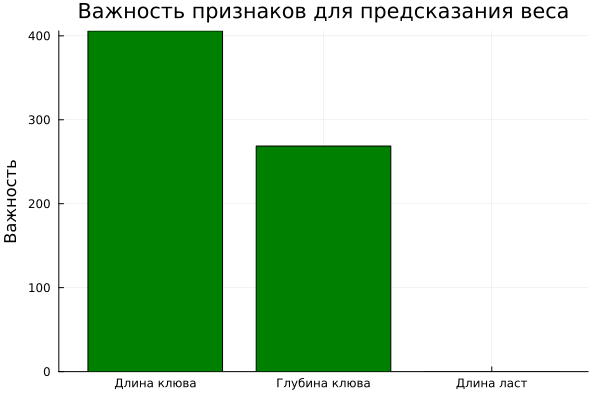

График важности признаков сохранен как 'feature_importance.png'

 ВСЕ ГРАФИКИ СОХРАНЕНЫ!
Графики сохранены как 'regression_plot.png' и 'feature_importance.png'


In [24]:
p = bar(feature_importance.Важность, xticks=(1:3, feature_importance.Признак),
    legend=false, title="Важность признаков для предсказания веса",
    ylabel="Важность", seriescolor=:green, size=(600, 400))

display(p)  #видиымй результат
savefig("feature_importance.png")

println("График важности признаков сохранен как 'feature_importance.png'")
println("\n ВСЕ ГРАФИКИ СОХРАНЕНЫ!")
println("Графики сохранены как 'regression_plot.png' и 'feature_importance.png'")